In [9]:
from pathlib import Path
import torch
import librosa
import soundfile
import numpy as np
import sys
sys.path.append(str((Path.home()/"github/Audio2AudioEchoes/ddsp").absolute()))
sys.path.append(str((Path.home()/"github/Audio2AudioEchoes/src").absolute()))
print(sys.path)
from model import DDSPDecoder
import glob
import json
import os
from tqdm import tqdm
from collections import defaultdict
import argparse
import itertools
from multiprocessing import Pool
from matplotlib import pyplot as plt

from echohiding import get_cepstrum, get_z_score

['/usr/lib/python310.zip', '/usr/lib/python3.10', '/usr/lib/python3.10/lib-dynload', '', '/home/tsroka/github/Audio2AudioEchoes/.venv/lib/python3.10/site-packages', '~/github/Audio2AudioEchoes/ddsp', '~/github/Audio2AudioEchoes/src', PosixPath('/home/tsroka/github/Audio2AudioEchoes/evaluation/finetuning/~/github/Audio2AudioEchoes/ddsp'), PosixPath('/home/tsroka/github/Audio2AudioEchoes/evaluation/finetuning/~/github/Audio2AudioEchoes/src'), PosixPath('/home/tsroka/github/Audio2AudioEchoes/evaluation/finetuning/~/github/Audio2AudioEchoes/ddsp'), PosixPath('/home/tsroka/github/Audio2AudioEchoes/evaluation/finetuning/~/github/Audio2AudioEchoes/src'), PosixPath('/github/Audio2AudioEchoes/ddsp'), PosixPath('/github/Audio2AudioEchoes/src'), PosixPath('/github/Audio2AudioEchoes/ddsp'), PosixPath('/github/Audio2AudioEchoes/src'), PosixPath('/github/Audio2AudioEchoes/ddsp'), PosixPath('/github/Audio2AudioEchoes/src'), '/github/Audio2AudioEchoes/ddsp', '/github/Audio2AudioEchoes/src', '/home/tsr

In [46]:
dataset = Path.home()/"datasets/raw/guitarset"
print(dataset)
pattern = "*.wav"

/home/tsroka/datasets/raw/guitarset


{'groove_75_full_dataset': [PosixPath('/home/tsroka/github/Audio2AudioEchoes/finetune_outputs/groove_75_full_dataset/7.pkl'), PosixPath('/home/tsroka/github/Audio2AudioEchoes/finetune_outputs/groove_75_full_dataset/2.pkl'), PosixPath('/home/tsroka/github/Audio2AudioEchoes/finetune_outputs/groove_75_full_dataset/6.pkl'), PosixPath('/home/tsroka/github/Audio2AudioEchoes/finetune_outputs/groove_75_full_dataset/9.pkl'), PosixPath('/home/tsroka/github/Audio2AudioEchoes/finetune_outputs/groove_75_full_dataset/12.pkl'), PosixPath('/home/tsroka/github/Audio2AudioEchoes/finetune_outputs/groove_75_full_dataset/10.pkl'), PosixPath('/home/tsroka/github/Audio2AudioEchoes/finetune_outputs/groove_75_full_dataset/5.pkl'), PosixPath('/home/tsroka/github/Audio2AudioEchoes/finetune_outputs/groove_75_full_dataset/0.pkl'), PosixPath('/home/tsroka/github/Audio2AudioEchoes/finetune_outputs/groove_75_full_dataset/8.pkl'), PosixPath('/home/tsroka/github/Audio2AudioEchoes/finetune_outputs/groove_75_full_dataset

/home/tsroka/github/Audio2AudioEchoes/.venv/lib/python3.10/site-packages/librosa/core/convert.py:1869: RuntimeWarning: divide by zero encountered in log10
  + 2 * np.log10(f_sq)


Elapsed time synth: 0.17765235900878906
Doing idx 0 file /home/tsroka/datasets/raw/guitarset/03_Jazz1-200-B_solo_mic.wav, 1/360, length 14 sec
Elapsed time pitch: 0.054289817810058594
Elapsed time synth: 0.17884087562561035
Doing idx 0 file /home/tsroka/datasets/raw/guitarset/03_Jazz1-200-B_solo_mic.wav, 1/360, length 14 sec
Elapsed time pitch: 0.055837392807006836
Elapsed time synth: 0.21795034408569336
Doing idx 0 file /home/tsroka/datasets/raw/guitarset/03_Jazz1-200-B_solo_mic.wav, 1/360, length 14 sec
Elapsed time pitch: 0.055303096771240234
Elapsed time synth: 0.18025660514831543
Doing idx 0 file /home/tsroka/datasets/raw/guitarset/03_Jazz1-200-B_solo_mic.wav, 1/360, length 14 sec
Elapsed time pitch: 0.05701088905334473
Elapsed time synth: 0.17823553085327148
Doing idx 0 file /home/tsroka/datasets/raw/guitarset/03_Jazz1-200-B_solo_mic.wav, 1/360, length 14 sec
Elapsed time pitch: 0.05420827865600586
Elapsed time synth: 0.1795940399169922
Doing idx 0 file /home/tsroka/datasets/raw/

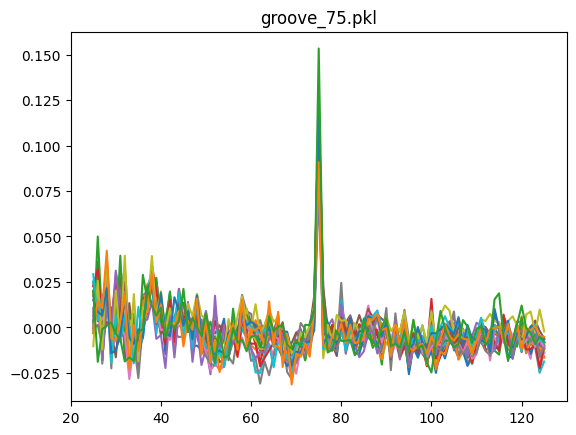

In [89]:
## Define parameter variations
instruments = ["other"]
echoes = [75]
durs = [5]#, 10, 30, 60]


def eval_echo_models(param, model_path):
    """
    Z-score evaluation for single echo style transfer 
    """
    (idx, opt) = param
    (instrument, echo, dur) = list(itertools.product(instruments, echoes, durs))[idx]
    out_path = f"evaluation/results/ddsp_{instrument}_{echo}_dur{dur}.json"

    torch.set_grad_enabled(False)
    files = list(dataset.glob(pattern))
    sr = opt.sr
    
    results = {}
    if os.path.exists(out_path):
        results = json.load(open(out_path))
    if not os.path.exists(model_path):
        print(model_path, "doesn't exist!  Aborting")
        return
    
    model = DDSPDecoder(3, 512, 50, 65, 441, opt.sr, opt.sr)
    model.load_from_file(model_path)

    for fidx, f in [(0,files[0])]:
        torch.cuda.empty_cache()
        results[model_path.name] = defaultdict(lambda: [])
        x, _ = librosa.load(f, sr=sr)
        print(f"Doing idx {idx} file {f}, {fidx+1}/{len(files)}, length {x.size//sr} sec")
        with torch.no_grad():
            y = model.style_transfer(x, "cpu", "cuda")
            soundfile.write("out.wav",y,44100)
        if y.size < dur*sr:
            print(f, "too short for", dur)
            continue
        chunks_this_time = min(opt.n_chunks, 2*y.size//(dur*sr))
        for _ in range(chunks_this_time):
            i1 = np.random.randint(y.size-dur*sr) # Choose a random offset
            cep = get_cepstrum(y[i1:i1+sr*dur])
            csort = np.array(cep[0:opt.lag_end+1])
            plt.plot(range(opt.lag_start, opt.lag_end+1), csort[opt.lag_start:])
            plt.title(Path(model_path).name)
            #plt.show()
            csort[0:opt.lag_start] = -np.inf
            ranks = np.zeros(csort.size)
            ranks[np.argsort(-csort)] = np.arange(csort.size)
            for test_echo in echoes:
                z_score = get_z_score(cep[0:opt.lag_end+1], test_echo, start_buff=opt.lag_start)
                rank = ranks[test_echo]
    return z_score, rank

subpaths = ["groove_75_full_dataset","groove_75_10_samples"]
base = Path("../../finetune_outputs").resolve()
models = {s:list((base/s).glob("*.pkl")) for s in subpaths}
print(models)

opt = argparse.Namespace(n_chunks=1,sr=44100,lag_start=25,lag_end=125)
res = {}
for model in models:
    res[model] = {}
    print(model)
    for checkpoint in models[model]:
        z_score, rank = eval_echo_models((0, opt),checkpoint)
        res[model][int(checkpoint.stem)] = z_score
for x in res.items():
    print(x)

# get baseline values
z_score_baseline, rank = eval_echo_models((0,opt),Path("../../ArtistProtectModels/SingleEchoes/DDSP/groove_75.pkl").resolve())

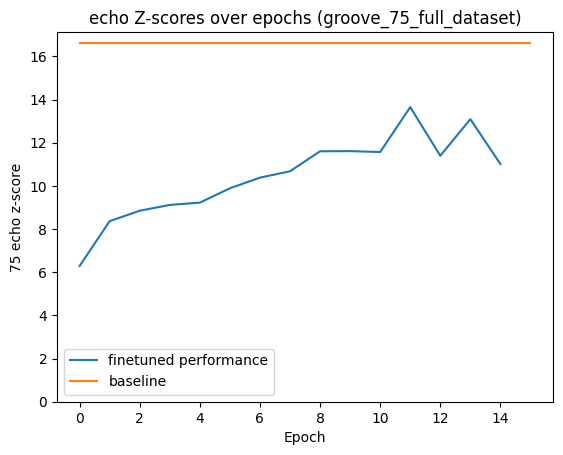

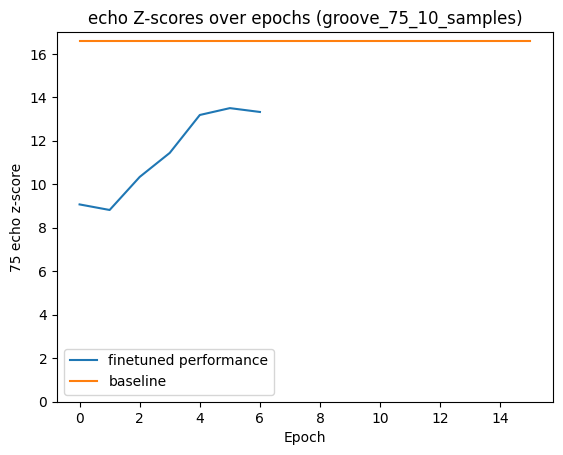

In [100]:
x_axis = max(len(res[m]) for m in res)
for model in res:
    sorted_z_scores = []
    for k in sorted(res[model].keys()):
        sorted_z_scores.append(res[model][k])

    plt.plot(sorted_z_scores, label="finetuned performance")
    plt.title(f"echo Z-scores over epochs ({model})")
    plt.xlabel("Epoch")
    plt.ylabel("75 echo z-score")
    plt.plot([0,x_axis],[z_score_baseline,z_score_baseline], label="baseline")
    plt.ylim(bottom=0)
    plt.legend()
    plt.show()